### Import Libraries

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

### Load MIMIC Tables

In [2]:
import os

data_location = "../../Dataset/mimic-iii-clinical-database-1.4/"
print(os.path.exists(data_location))

True


In [3]:
patients = pd.read_csv(data_location + "PATIENTS.csv.gz")
admissions = pd.read_csv(data_location + "ADMISSIONS.csv.gz")
icustays = pd.read_csv(data_location + "ICUSTAYS.csv.gz")

In [4]:
notes = pd.read_csv(
    data_location + "NOTEEVENTS.csv.gz",
    compression='gzip',
    dtype={
        'SUBJECT_ID': 'int32',
        'HADM_ID': 'float32',   # some rows missing
        'CATEGORY': 'category',
        'DESCRIPTION': 'category'
    },
    parse_dates=['CHARTDATE', 'CHARTTIME'],
    low_memory=False
)

In [5]:
chart = pd.read_csv(
    data_location + "CHARTEVENTS.csv.gz",
    usecols=["SUBJECT_ID","HADM_ID","ITEMID","VALUENUM","CHARTTIME"],
    compression="gzip"
)

vital_ids = [
211,   # Heart Rate
220045,# Heart Rate (Metavision)
220179,# Non-invasive BP systolic
220180,# Non-invasive BP diastolic
220210,# Respiratory Rate
223761 # Temperature
]

chart = chart[chart["ITEMID"].isin(vital_ids)]

vitals = chart.groupby(["SUBJECT_ID","HADM_ID","ITEMID"])["VALUENUM"].mean().unstack()

vitals.reset_index(inplace=True)

In [6]:
labs = pd.read_csv(data_location + "LABEVENTS.csv.gz")

lab_ids = [
50882, # Bicarbonate for Acid-Base Balance
50868, # Anion Gap
50912, # Creatinine for Kidney Function
51301, # WBC for Infection/Inflammation
51222,  # Hemoglobin for oxygen carrying capacity
51006,  # BUN for Kidney Function
51265,  # Platelet Count for Clotting
50931,  # Glucose for Diabetes
50983,  # Sodium for Electrolyte Balance
50971,  # Potassium for Cardiac stability
50882  # Bicarbonate for Acid-Base Balance
]

labs = labs[labs["ITEMID"].isin(lab_ids)]

lab_features = labs.groupby(["SUBJECT_ID","HADM_ID","ITEMID"])["VALUENUM"].mean().unstack()

lab_features.reset_index(inplace=True)

### Feature Extraction

In [7]:
data = icustays.merge(admissions, on=["SUBJECT_ID","HADM_ID"])
data = data.merge(patients, on="SUBJECT_ID")

In [8]:
data = data.merge(vitals, on=["SUBJECT_ID","HADM_ID"], how="left")
data = data.merge(lab_features, on=["SUBJECT_ID","HADM_ID"], how="left")

In [9]:

data["ADMITTIME"] = pd.to_datetime(data["ADMITTIME"], errors="coerce")
data["DOB"] = pd.to_datetime(data["DOB"], errors="coerce")


data["AGE"] = data["ADMITTIME"].dt.year - data["DOB"].dt.year
data.loc[data["AGE"] > 89, "AGE"] = 90

data = data[(data["AGE"] > 0) & (data["AGE"] < 120)]

data["AGE"].count()

# data.head()

53452

In [10]:
# AGE
# GENDER
# ADMISSION_TYPE
# ADMISSION_LOCATION

# Heart Rate - 211
# Respiratory Rate - 220210
# Systolic BP - 220179
# Diastolic BP - 220180
# Temperature

# Creatinine (50912)
# BUN (51006)
# WBC (51301)
# Hemoglobin (51222)
# Platelets (51265)
# Sodium (50983)
# Potassium (50971)

df = data[
[
"AGE",
"GENDER",
"LOS",
"ADMISSION_TYPE",
"ADMISSION_LOCATION",
211,
220210,
220179,
220180,
50912,
51006,
51301,
51222,
51265,
50983,
50971,
"HOSPITAL_EXPIRE_FLAG",
]
].copy()

df = df.rename(columns={
    211: "HeartRate",
    220210: "RespiratoryRate",
    220179: "SystolicBP",
    220180: "DiastolicBP",
    50912: "Creatinine",
    51006: "BUN",
    51301: "WBC",
    51222: "Hemoglobin",
    51265: "Platelets",
    50983: "Sodium",
    50971: "Potassium"
})

#df.dropna()


In [11]:

df = df.fillna(df.median(numeric_only=True))

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53452 entries, 0 to 61531
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   AGE                   53452 non-null  int32  
 1   GENDER                53452 non-null  object 
 2   LOS                   53452 non-null  float64
 3   ADMISSION_TYPE        53452 non-null  object 
 4   ADMISSION_LOCATION    53452 non-null  object 
 5   HeartRate             53452 non-null  float64
 6   RespiratoryRate       53452 non-null  float64
 7   SystolicBP            53452 non-null  float64
 8   DiastolicBP           53452 non-null  float64
 9   Creatinine            53452 non-null  float64
 10  BUN                   53452 non-null  float64
 11  WBC                   53452 non-null  float64
 12  Hemoglobin            53452 non-null  float64
 13  Platelets             53452 non-null  float64
 14  Sodium                53452 non-null  float64
 15  Potassium             53

### Data Visualization 

##### Mortality Distribution

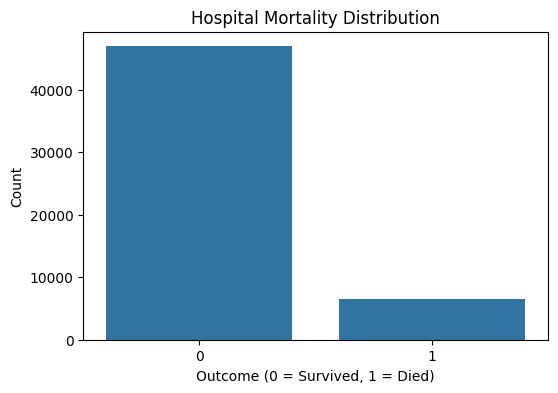

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="HOSPITAL_EXPIRE_FLAG", data=df)

plt.title("Hospital Mortality Distribution")
plt.xlabel("Outcome (0 = Survived, 1 = Died)")
plt.ylabel("Count")

plt.savefig("images/hospital_mortality_bar_chart.png", dpi=300, bbox_inches="tight")

plt.show()

##### ICU Length of Stay Distribution

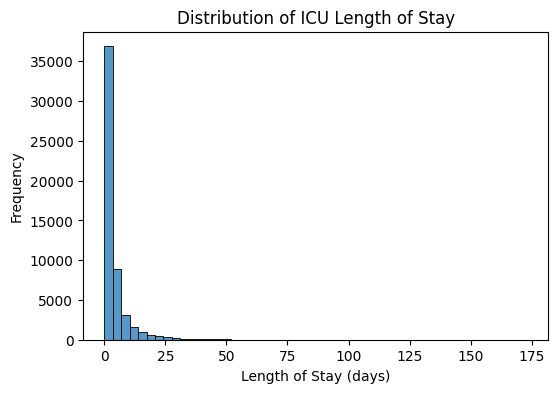

In [13]:
plt.figure(figsize=(6,4))

sns.histplot(df["LOS"], bins=50)

plt.title("Distribution of ICU Length of Stay")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Frequency")

plt.savefig("images/icu_length_of_stay_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

### Training/Testing Data Split

In [14]:
X = df.drop("HOSPITAL_EXPIRE_FLAG", axis=1)
y = df["HOSPITAL_EXPIRE_FLAG"]

X.columns = X.columns.astype(str)

In [15]:
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Because mortality datasets are imbalanced such as Survived: 90%, Died: 10%
)

print(X_train.shape)
print(y_train.shape)

(42761, 25)
(42761,)


### Logistic Regression Model

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train_scaled, y_train)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]

In [18]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)

auc_lr = roc_auc_score(y_test, lr_prob)

##### ROC Curve for Logistic Regression Model

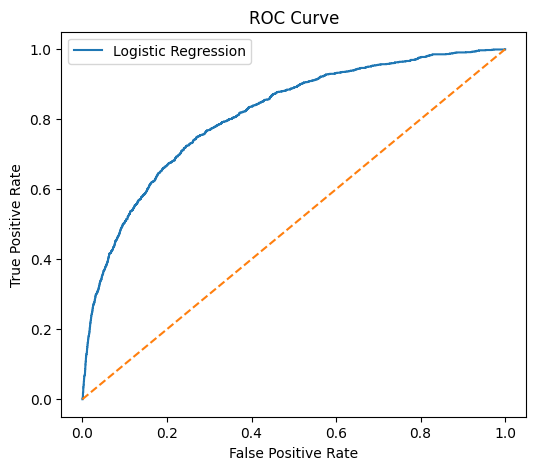

In [19]:
plt.figure(figsize=(6,5))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.savefig("images/roc_curve_logistic_regression.png", dpi=300, bbox_inches="tight")

plt.show()

##### Logistic Regression: Top Features Increasing Mortality Risk

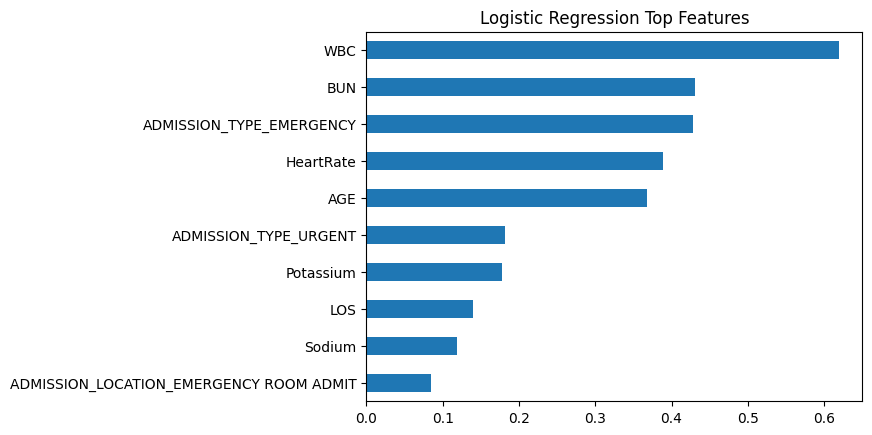

In [20]:
coef = pd.Series(
    lr.coef_[0],
    index=X_train.columns
).sort_values()

coef.tail(10).plot(kind="barh")
plt.title("Logistic Regression Top Features")

plt.savefig("images/logistic_regression_top_features.png", dpi=300, bbox_inches="tight")
plt.show()


### Random Forest Model

In [21]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred_prob = rf.predict_proba(X_test)[:,1]


In [22]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_prob)

auc_rf = roc_auc_score(y_test, rf_pred_prob)

##### ROC Curve for Random Forrest Classifier

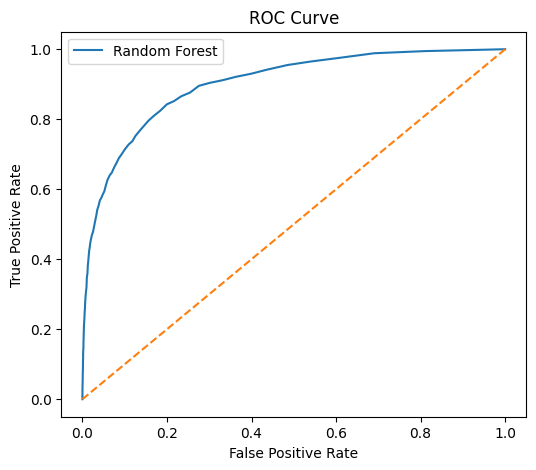

In [23]:
plt.figure(figsize=(6,5))

plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.savefig("images/roc_curve_random_forest.png", dpi=300, bbox_inches="tight")

plt.show()

##### Random Forest Model - Top Features

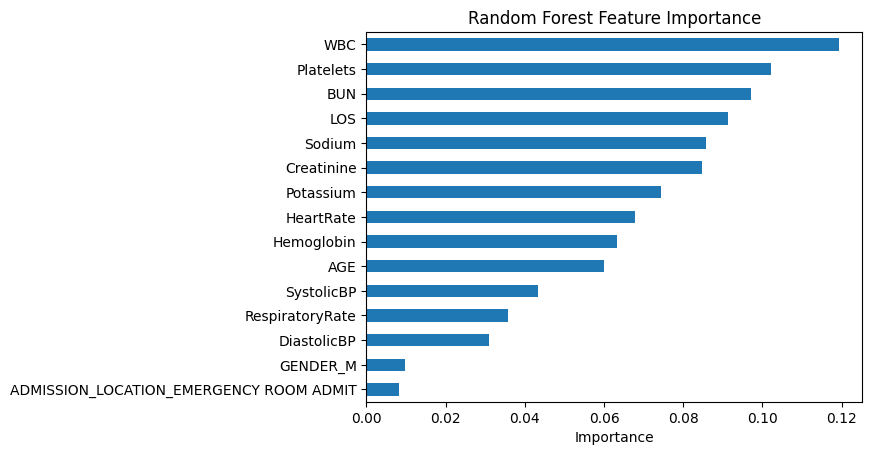

In [24]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# feature_importance.head(15).plot(kind="barh")

feature_importance.head(15).sort_values().plot(kind="barh")

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance")
plt.savefig("images/random_forest_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()


### NLP — TF-IDF from Clinical Notes

In [25]:
notes_subset = notes[
    notes["CATEGORY"].isin([
        "Nursing",
        "Physician",
        "Radiology"
    ])
]

# notes_subset = notes[
#     (notes["CATEGORY"].isin(["Nursing","Physician","Radiology"])) &
#     (notes["CHARTTIME"] <= notes["CHARTDATE"] + pd.Timedelta(hours=48))
# ]

notes_subset = notes_subset.merge(
    admissions[["HADM_ID", "HOSPITAL_EXPIRE_FLAG"]],
    on="HADM_ID",
    how="inner"
)

texts = notes_subset["TEXT"].fillna("").tolist()[:10000]

y_text = notes_subset["HOSPITAL_EXPIRE_FLAG"].iloc[:10000]

In [26]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Create custom stop word list
stop_words = set(ENGLISH_STOP_WORDS)

stop_words.update([
    "patient",
    "history",
    "medical",
    "noted",
    "noting",
    "present",
    "reported",
    "expired",
    "death",
    "dead",
    "comfort",
    "dnr",
    "withdrawal",
    "family",
    "meeting",
    "mg","ml","po","iv","bid","tid","q4h","q6h",
    "tablet","capsule","dose","daily"
])


# Convert to list
stop_words = list(stop_words)

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=stop_words,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9
)

X_text = vectorizer.fit_transform(texts)

##### Train/Test Split for NLP

In [27]:
X_train_tfidf, X_test_tfidf, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.2,
    random_state=42,
    stratify=y_text
)

##### Train NLP Model

In [28]:
nlp_model = LogisticRegression(max_iter=2000)

nlp_model.fit(X_train_tfidf, y_train_text)

nlp_prob = nlp_model.predict_proba(X_test_tfidf)[:,1]

In [29]:
fpr_nlp, tpr_nlp, _ = roc_curve(y_test_text, nlp_prob)

auc_nlp = roc_auc_score(y_test_text, nlp_prob)

##### ROC Curve for NLP Based Classifier

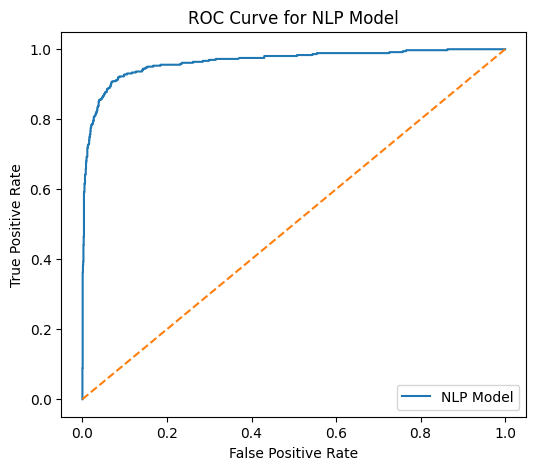

In [30]:
plt.figure(figsize=(6,5))

# plt.plot(fpr_nlp, tpr_nlp, label=f"NLP Model (AUC = {auc_nlp:.2f}")

plt.plot(fpr_nlp, tpr_nlp, label=f"NLP Model")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for NLP Model")

plt.legend()

plt.savefig("images/roc_curve_nlp.png", dpi=300, bbox_inches="tight")

plt.show()

##### Top NLP Features For Predicting Mortality

In [31]:
feature_names = vectorizer.get_feature_names_out()

coefficients = nlp_model.coef_[0]

top_positive = coefficients.argsort()[-15:]

for i in top_positive:
    print(feature_names[i])

shock
alteration
cardiogenic
pressors
morphine gtt
cmo
gvhd
brain
arrest
eeg
dilantin
care
2177
morphine
levophed


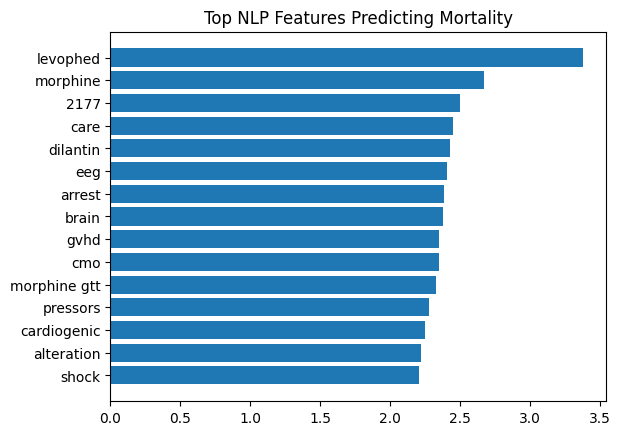

In [32]:
top = coefficients.argsort()[-15:]

plt.barh(
    feature_names[top],
    coefficients[top]
)

plt.title("Top NLP Features Predicting Mortality")
plt.savefig("images/nlp_top_features.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
import numpy as np

bigram_features = [f for f in feature_names if " " in f]

bigram_idx = [i for i,f in enumerate(feature_names) if " " in f]

bigram_coefs = coefficients[bigram_idx]

top_bigram_idx = np.argsort(bigram_coefs)[-15:]

for i in top_bigram_idx:
    print(bigram_features[i])

right arm
response abg
alteration nutrition
ulcerative colitis
female admitted
kg min
ovarian ca
septic assessment
shock septic
cell lymphoma
hip pain
thrombocytopenia chronic
pleural effusion
large cell
morphine gtt


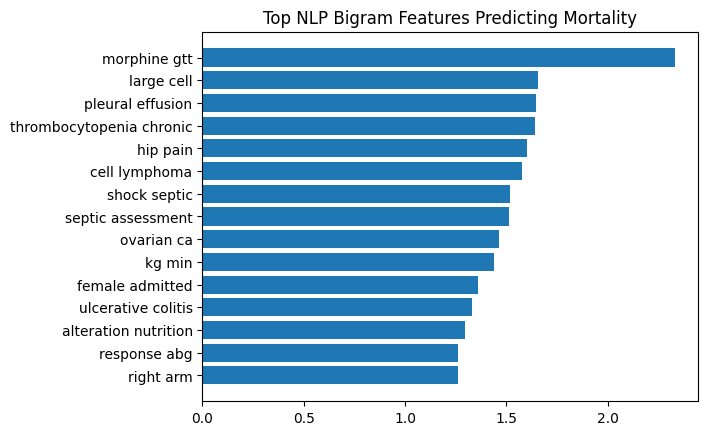

In [34]:
bigram_features = np.array(bigram_features)


top = bigram_coefs.argsort()[-15:]

plt.barh(
    bigram_features[top],
    bigram_coefs[top]
)

plt.title("Top NLP Bigram Features Predicting Mortality")
plt.savefig("images/nlp_top_bigram_features.png", dpi=300, bbox_inches="tight")
plt.show()

##### TSNE Visualization of Text Features

t-SNE (t-distributed Stochastic Neighbor Embedding) is useful for the NLP model because it helps visualize high-dimensional text representations and semantic relationships between clinical notes, and t-SNE helps visualize the relationships between those text features in a 2D or 3D space. This helps to verify that the NLP embeddings are capturing meaningful semantic patterns.

Other models rely on structured numerical features that are better interpreted through feature importance rather than dimensionality reduction.

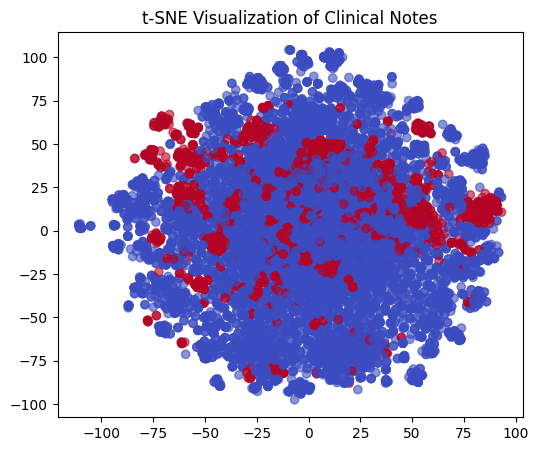

In [35]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)

text_tsne = tsne.fit_transform(X_text.toarray())

plt.figure(figsize=(6,5))

plt.scatter(
    text_tsne[:,0],
    text_tsne[:,1],
    c=y_text,
    cmap="coolwarm",
    alpha=0.6
)

plt.title("t-SNE Visualization of Clinical Notes")

plt.savefig("images/tsne_visualization_nlp.png", dpi=300, bbox_inches="tight")
plt.show()

### Deep Learning Model (Neural Network)

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim

In [37]:
# StandardScaler normalizes the features so they have: Mean = 0, Standard deviation = 1

scaler = StandardScaler()  # Neural networks train more efficiently when input features are on similar scales.

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)  # Converts the scaled NumPy array into a PyTorch tensor.
y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).unsqueeze(1)

##### Neural Network

In [38]:
class MortalityNN(nn.Module):

    def __init__(self,input_dim):        # input_dim represents number of input features
        super().__init__()

        # nn.Sequential builds a layer-by-layer neural network pipeline.
        # Input → Linear → ReLU → Dropout → Linear → Output
        # 1. First Linear Layer - Transforms input features -> 32 hidden neurons.
        # 2. activation function that introduces non-linearity, allowing the model to learn complex patterns.
        # 3. Randomly turns off 30% of neurons during training to prevent overfitting.
        # 4. Converts 32 hidden neurons → 1 output neuron.Predicts mortality probability for binary classification.

        self.net = nn.Sequential(
            nn.Linear(input_dim,32),   
            nn.ReLU(),      
            nn.Dropout(0.3),            
            nn.Linear(32,1)   
        )

    # Defines how input flows through the network. Train network using forward pass + backpropagation
    def forward(self,x):
        return self.net(x)

In [39]:
# Initialize model.

model = MortalityNN(X_train.shape[1])

criterion = nn.BCEWithLogitsLoss() # Binary Cross Entropy with Logits Loss, Used for binary classification.

# Adam optimizer updates the model weights to minimize loss.

# Adaptive learning rate algorithm.
# Combines momentum + RMSProp ideas.
# Very effective for deep learning.

# Parameters:

# model.parameters() → all weights and biases

# lr=0.001 → learning rate

# Learning rate controls how big each weight update step is.

optimizer = optim.Adam(model.parameters(),lr=0.001) 

##### Training Loss Curve

In [40]:
losses = []

# Runs the training process for 50 epochs. An epoch means one full pass through the entire training dataset.
# Multiple epochs allow the neural network to gradually adjust its weights and improve predictions.
for epoch in range(50): 

    # Clears the previous gradients stored in the model.
    optimizer.zero_grad()  

    outputs = model(X_train_tensor)

    # Computes the loss function using BCEWithLogitsLoss.
    loss = criterion(outputs,y_train_tensor)

    # Performs backpropagation
    loss.backward()

    # Updates the model weights using the computed gradients
    optimizer.step()

    losses.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.6509
Epoch 2, Loss: 0.6461
Epoch 3, Loss: 0.6411
Epoch 4, Loss: 0.6364
Epoch 5, Loss: 0.6317
Epoch 6, Loss: 0.6272
Epoch 7, Loss: 0.6233
Epoch 8, Loss: 0.6188
Epoch 9, Loss: 0.6143
Epoch 10, Loss: 0.6101
Epoch 11, Loss: 0.6062
Epoch 12, Loss: 0.6017
Epoch 13, Loss: 0.5970
Epoch 14, Loss: 0.5929
Epoch 15, Loss: 0.5893
Epoch 16, Loss: 0.5849
Epoch 17, Loss: 0.5813
Epoch 18, Loss: 0.5771
Epoch 19, Loss: 0.5732
Epoch 20, Loss: 0.5700
Epoch 21, Loss: 0.5662
Epoch 22, Loss: 0.5620
Epoch 23, Loss: 0.5589
Epoch 24, Loss: 0.5554
Epoch 25, Loss: 0.5520
Epoch 26, Loss: 0.5475
Epoch 27, Loss: 0.5442
Epoch 28, Loss: 0.5411
Epoch 29, Loss: 0.5375
Epoch 30, Loss: 0.5340
Epoch 31, Loss: 0.5311
Epoch 32, Loss: 0.5276
Epoch 33, Loss: 0.5240
Epoch 34, Loss: 0.5210
Epoch 35, Loss: 0.5177
Epoch 36, Loss: 0.5145
Epoch 37, Loss: 0.5112
Epoch 38, Loss: 0.5085
Epoch 39, Loss: 0.5056
Epoch 40, Loss: 0.5025
Epoch 41, Loss: 0.4994
Epoch 42, Loss: 0.4969
Epoch 43, Loss: 0.4938
Epoch 44, Loss: 0.49

##### Training Loss Curve

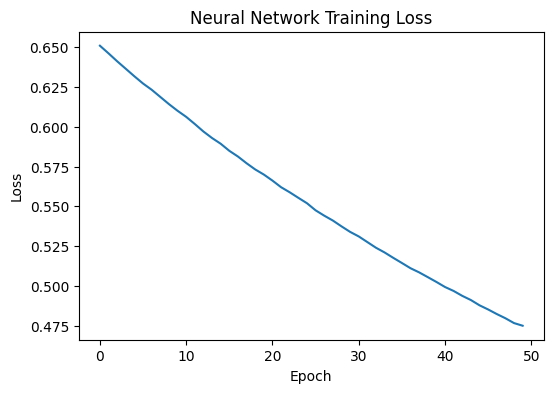

In [41]:
plt.figure(figsize=(6,4))

plt.plot(losses)

plt.title("Neural Network Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig("images/neural_network_training_loss.png", dpi=300, bbox_inches="tight")

plt.show()

##### Neural Network Predictions

In [42]:
with torch.no_grad():

    logits = model(torch.tensor(X_test_scaled, dtype=torch.float32))

    nn_probs = torch.sigmoid(logits).numpy().flatten()

In [43]:
# Compute ROC curve and AUC for NN

fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_probs)
    
auc_nn = roc_auc_score(y_test, nn_probs)

##### ROC Curve for Deep Learning Classifier

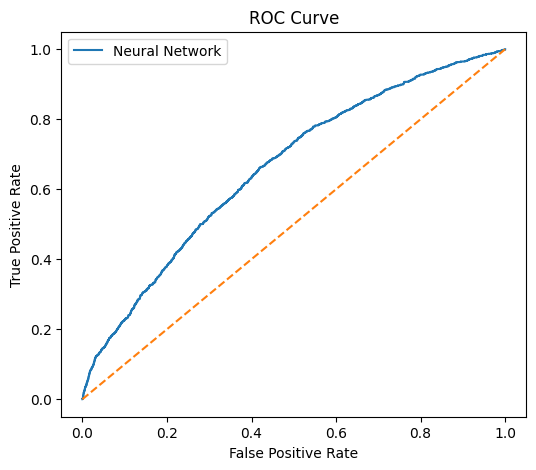

In [44]:
plt.figure(figsize=(6,5))

plt.plot(fpr_nn, tpr_nn, label="Neural Network")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.savefig("images/roc_curve_neural_network.png", dpi=300, bbox_inches="tight")

plt.legend()

plt.show()

##### Neural Network Feature Importance

In [45]:
from sklearn.metrics import accuracy_score
import numpy as np

baseline = accuracy_score(
    y_test,
    (model(torch.tensor(X_test_scaled, dtype=torch.float32))
     .detach().numpy().flatten() > 0.5)
)

importances = []

for i in range(X_test_scaled.shape[1]):
    
    X_permuted = X_test_scaled.copy()
    np.random.shuffle(X_permuted[:, i])
    
    preds = model(torch.tensor(X_permuted, dtype=torch.float32))
    preds = (preds.detach().numpy().flatten() > 0.5)
    
    score = accuracy_score(y_test, preds)
    
    importances.append(baseline - score)

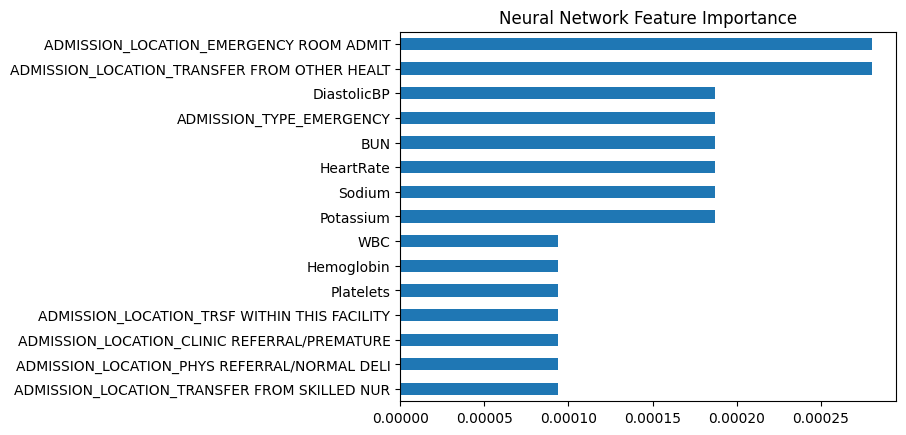

In [46]:
# pd.Series(importances, index=X_test.columns)\
#     .sort_values()\
#     .tail(15)\
#     .plot(kind="barh")

importance = pd.Series(importances, index=X_test.columns)

importance = importance.abs().sort_values(ascending=False)

importance.head(15).sort_values().plot(kind="barh")

plt.title("Neural Network Feature Importance")
plt.savefig("images/neural_network_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

### Multimodal Pipeline

In [47]:
# X contains structured clinical variables (e.g., age, gender, labs, vitals) and is preprocessed with one-hot encoding for categorical features. Machine learning models require numeric input, so categorical variables must be encoded.
X_struct = X 
X_struct = pd.get_dummies(X_struct, drop_first=True)


# text features from NLP model
vectorizer = TfidfVectorizer(max_features=2000)
X_text = vectorizer.fit_transform(texts)

# TF-IDF produces a sparse matrix. Convert text sparse matrix to Dataframe
X_text = pd.DataFrame(X_text.toarray())

# combine structured + text Features
X_multi = pd.concat([X_struct.reset_index(drop=True),
                     X_text.reset_index(drop=True)], axis=1)

# Convert Column Names to Strings
X_multi.columns = X_multi.columns.astype(str)

In [48]:
X_multi_train, X_multi_test, y_train, y_test = train_test_split(
    X_multi,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
rf_multi = RandomForestClassifier(n_estimators=100)

rf_multi.fit(X_multi_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
multi_prob = rf_multi.predict_proba(X_multi_test)[:,1]

fpr_multi, tpr_multi, _ = roc_curve(y_test, multi_prob)

auc_multi = roc_auc_score(y_test, multi_prob)

##### Top features in Multimodal model

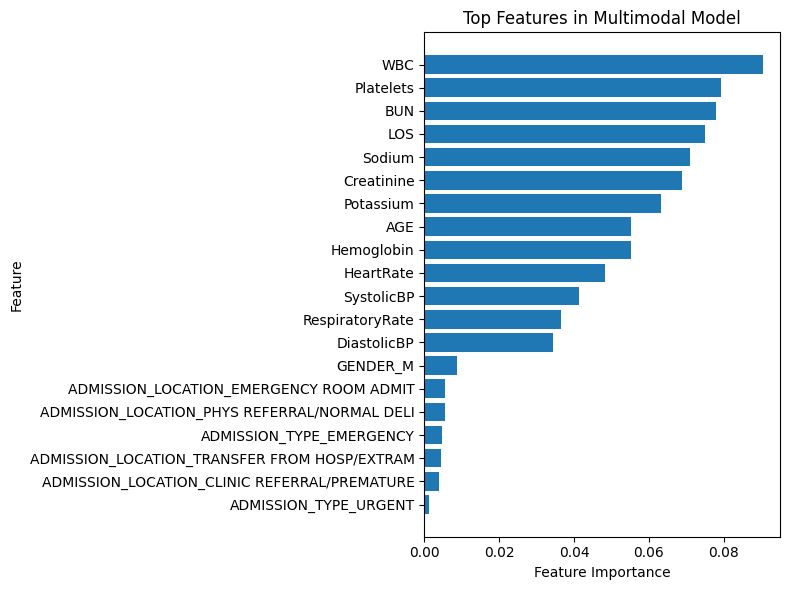

In [51]:

# Get feature importances from the trained random forest
importances = rf_multi.feature_importances_

# Get feature names
feature_names = X_multi_train.columns

# Create dataframe
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

# Select top 20 features
top_features = feature_importance_df.head(20)

# Plot
plt.figure(figsize=(8,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top Features in Multimodal Model")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig("images/multimodal_top_features.png", dpi=300, bbox_inches="tight")
plt.show()

##### ROC Curve for Multi-modal Classifier

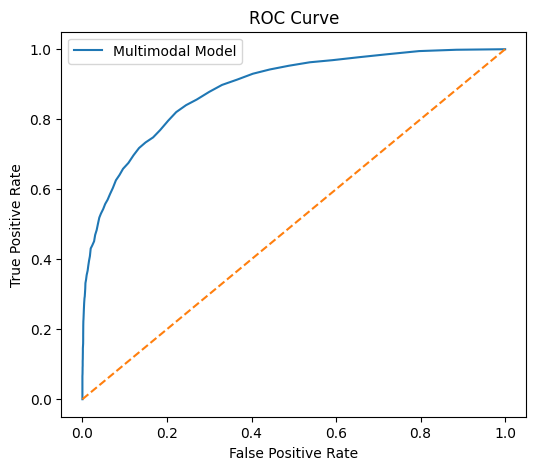

In [52]:
plt.figure(figsize=(6,5))

plt.plot(fpr_multi, tpr_multi, label="Multimodal Model")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.savefig("images/roc_curve_multimodal.png", dpi=300, bbox_inches="tight")

plt.show()

### Model Performance Comparison Chart

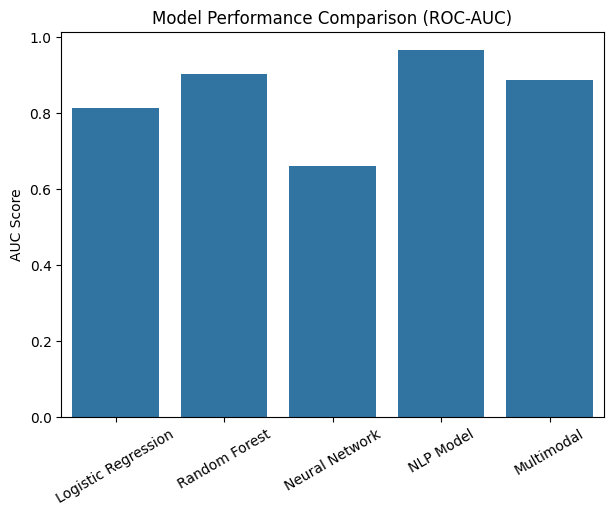

In [53]:
models = ["Logistic Regression","Random Forest",
          "Neural Network","NLP Model","Multimodal"]

auc_scores = [auc_lr,auc_rf,auc_nn,auc_nlp,auc_multi]

plt.figure(figsize=(7,5))

sns.barplot(x=models,y=auc_scores)

plt.title("Model Performance Comparison (ROC-AUC)")
plt.ylabel("AUC Score")

plt.xticks(rotation=30)

plt.savefig("images/model_performance_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

##### Combined ROC Curves

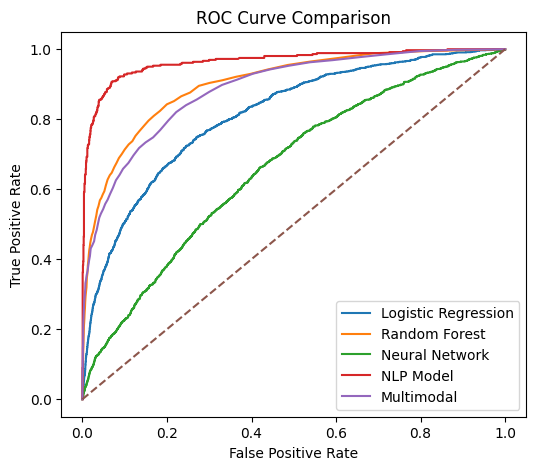

In [54]:
plt.figure(figsize=(6,5))

plt.plot(fpr_lr,tpr_lr,label="Logistic Regression")
plt.plot(fpr_rf,tpr_rf,label="Random Forest")
plt.plot(fpr_nn,tpr_nn,label="Neural Network")
plt.plot(fpr_nlp,tpr_nlp,label="NLP Model")
plt.plot(fpr_multi,tpr_multi,label="Multimodal")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.title("ROC Curve Comparison")

plt.savefig("images/roc_curve_comparison.png", dpi=300, bbox_inches="tight")

plt.show()